In [2]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   -------------------------------------- - 1.3/1.4 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 5.0 MB/s  0:00:00


Train shape: (10578, 16), Test shape: (3527, 15)
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1114
[LightGBM] [Info] Number of data points in the train set: 8836, number of used features: 16
[LightGBM] [Info] Start training from score 450.000000
Validation MAE: 101.69510961147685


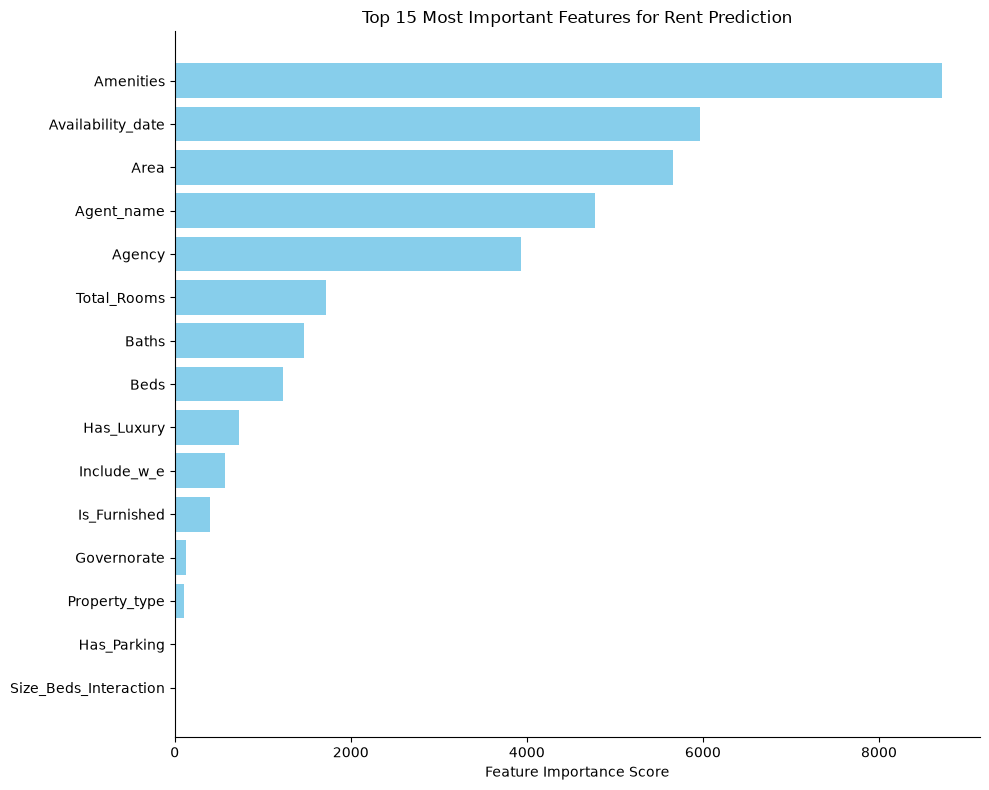

Submission file successfully created!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import lightgbm as lgb

# ---------------------------------------------------------
# 1. Load Raw Datasets
# ---------------------------------------------------------
train_df = pd.read_csv('./data.csv')
test_df = pd.read_csv('./test.csv')

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

# ---------------------------------------------------------
# 2. Remove Extreme Rent Outliers
# ---------------------------------------------------------
Q1 = train_df['rent'].quantile(0.01)
Q3 = train_df['rent'].quantile(0.99)
train_df = train_df[(train_df['rent'] >= Q1) & (train_df['rent'] <= Q3)].copy()

# ---------------------------------------------------------
# 3. Combine Datasets for Consistent Cleaning
# ---------------------------------------------------------
train_df['is_train'] = 1
test_df['is_train'] = 0
df = pd.concat([train_df, test_df], ignore_index=True)

# Clean 'Baths'
df['Baths'] = df['Baths'].astype(str).str.strip().replace({'7+': '8', 'none': '1'})
df['Baths'] = df['Baths'].astype(int)

# Clean 'Beds'
df['Beds'] = df['Beds'].astype(str).str.lower()
df['Beds'] = df['Beds'].replace({'studio': '1', 'studio+ maid': '1'})
df['Beds'] = df['Beds'].str.extract(r'(\d+)')[0].fillna(1).astype(int)

# Merge Rare Categories for Property_type and Area
if 'Property_type' in df.columns:
    counts = df['Property_type'].value_counts()
    rare_types = counts[counts < 20].index
    df['Property_type'] = df['Property_type'].replace(rare_types, 'Other')

if 'Area' in df.columns:
    counts = df['Area'].value_counts()
    rare_areas = counts[counts < 10].index
    df['Area'] = df['Area'].replace(rare_areas, 'Other')

# Fill Missing Text/Categorical Columns
cols_to_fill = ['Title', 'Area', 'Governorate', 'Agent_name', 'Agency', 'Availability_date', 'Amenities']
for col in cols_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# ---------------------------------------------------------
# 4. Advanced Feature Engineering
# ---------------------------------------------------------
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')
df['Total_Rooms'] = df['Beds'] + df['Baths']
df['Space_Per_Room'] = df['Size'] / (df['Total_Rooms'] + 1)
df['Size_Beds_Interaction'] = df['Size'] * df['Beds']

# Keyword extraction from Title
if 'Title' in df.columns:
    df['Title'] = df['Title'].astype(str).str.lower()
    df['Has_Luxury'] = df['Title'].str.contains('lux|luxury|deluxe|premium|vip', case=False, na=False).astype(int)
    df['Is_Furnished'] = df['Title'].str.contains('furnished|furnish', case=False, na=False).astype(int)
    df['Has_Parking'] = df['Title'].str.contains('parking|garage|car park', case=False, na=False).astype(int)

# Group-based Imputation for Size based on Area
if 'Area' in df.columns and 'Size' in df.columns:
    df['Size'] = df['Size'].fillna(df.groupby('Area')['Size'].transform('median'))
df['Size'] = df['Size'].fillna(df['Size'].median())

# ---------------------------------------------------------
# 5. Extract Train and Test Clean Sets
# ---------------------------------------------------------
train_clean = df[df['is_train'] == 1].copy()
test_clean = df[df['is_train'] == 0].drop(columns=['is_train', 'rent'], errors='ignore').copy()

drop_cols = ['rent', 'Property_id', 'is_train']
X = train_clean.drop(columns=[c for c in drop_cols if c in train_clean.columns]).copy()
y = pd.to_numeric(train_clean['rent'], errors='coerce')

X_test_final = test_clean.drop(columns=[c for c in drop_cols if c in test_clean.columns]).copy()

# Drop rows where target became NaN first
valid_idx = ~y.isna().to_numpy()
X = X.iloc[valid_idx].reset_index(drop=True)
y = y.iloc[valid_idx].reset_index(drop=True)

# Ensure test set has the exact same columns as train set
for col in X.columns:
    if col not in X_test_final.columns:
        X_test_final[col] = np.nan
X_test_final = X_test_final[X.columns]

# ---------------------------------------------------------
# 6. Native Type Conversion
# ---------------------------------------------------------
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        X_test_final[col] = X_test_final[col].fillna(median_val)
    else:
        X[col] = X[col].astype(str).fillna('Missing').astype('category')
        X_test_final[col] = X_test_final[col].astype(str).fillna('Missing').astype('category')

# ---------------------------------------------------------
# 7. Train-Validation Split & LightGBM Model (MAE Optimized)
# ---------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)

lgb_model = lgb.LGBMRegressor(
    objective='mae',          # Directly optimizes for MAE leaderboard metric
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_X=X_val,
    eval_y=y_val,
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# Validation evaluation
preds = lgb_model.predict(X_val)
val_mae = mean_absolute_error(y_val, preds)
print(f"Validation MAE: {val_mae}")

# ---------------------------------------------------------
# 8. Feature Importance Graph Visualization
# ---------------------------------------------------------
importances = lgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'][-15:], importance_df['Importance'][-15:], color='skyblue')
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Most Important Features for Rent Prediction')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 9. Final Prediction & Submission Generation
# ---------------------------------------------------------
final_predictions = lgb_model.predict(X_test_final)

submission = pd.DataFrame({
    'Property_id': test_df['Property_id'], 
    'rent': final_predictions
})
submission.to_csv('submission.csv', index=False)
print("Submission file successfully created!")